In [1]:
# from ultralytics import RTDETR

# model = RTDETR("rtdetr-l.pt")
# model.info()

# results = model.train(data='./Scananagrams.yolov8', epochs = 50, imgsz=640)

## Read in Image, Identify Tiles


image 1/1 c:\IzzysWorkshop\PeelBack\TestImage.jpg: 640x640 16 Tiles, 528.0ms
Speed: 3.3ms preprocess, 528.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
average Tile Length: 315.5625
Total tiles scanned: 16


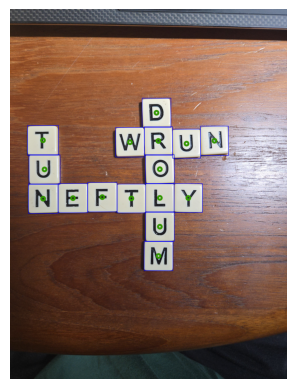

In [2]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import RTDETR
import numpy as np
from Scananagrams.src import helper


imagePath = 'TestImage.jpg'

image = cv2.imread(imagePath, cv2.IMREAD_COLOR_RGB)

drawOn = image.copy()

myModel = RTDETR('runs/detect/train/weights/best.pt')
result = myModel.predict(imagePath)

boxes = result[0].boxes.xyxy.cpu().numpy()
boxes = boxes.astype(np.int64)
centers = []

for x1,y1,x2,y2 in boxes:
    # x1,y1,x2,y2 = map(int,box)
    xAvg = (x1+x2)//2
    yAvg = (y1+y2)//2
    centers.append([xAvg,yAvg])

    cv2.circle(drawOn, (xAvg,yAvg),20,(50,150,0),20)
    cv2.rectangle(drawOn, (x1,y1),(x2,y2), (0,0,250),3)

centers = np.asarray(centers)

avgTileLen = helper.findNewAvgTileLen(boxes)

print(f'average Tile Length: {avgTileLen}')
print(f'Total tiles scanned: {len(boxes)}')
plt.imshow(drawOn)
plt.axis('off')
plt.show()

## Filter for duplicates and false positives

### Filter By Aspect Ratio 

In [3]:
heights = boxes[:,3] - boxes[:,1]
widths = boxes[:,2] - boxes[:,0]
aspectRatios = widths/heights

ratioMOE = .35
minRatio, maxRatio = helper.percentCI(1,ratioMOE)

conditions = (minRatio<aspectRatios) & (aspectRatios<maxRatio) 
boxes = boxes[conditions]
centers=centers[conditions]
len(boxes)

16

### Filter by Length and Width

In [4]:
#avgTileLen needs to be recalculated now that ratio has been filtered
avgTileLen = helper.findNewAvgTileLen(boxes)

heights = boxes[:,3] - boxes[:,1]
widths = boxes[:,2] - boxes[:,0]

lenMOE = .25
minLen,maxLen = helper.percentCI(avgTileLen,lenMOE)

conditions = (widths<maxLen) & (widths>minLen) & (heights>minLen) & (heights<maxLen) 
boxes = boxes[conditions]
centers=centers[conditions]
len(boxes)


16

### Filter For Duplicates

In [5]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=6, algorithm='ball_tree').fit(centers)
indices = neigh.kneighbors(centers, return_distance=False)

In [6]:
avgTileLen = helper.findNewAvgTileLen(boxes)

duplicates=[]
for neighbors in indices:
    mainTile = centers[neighbors[0]]
    for neighbor in neighbors[1:]:
        diffX = mainTile[0] - centers[neighbor][0]
        diffY = mainTile[1] - centers[neighbor][1]
        if ( abs(diffX) < avgTileLen/2 and abs(diffY) < avgTileLen/2 ):
            print(f'Overlap found - ({mainTile[0]},{mainTile[1]}) and ({centers[neighbor][0]},{centers[neighbor][1]}) ')
            if(neighbors[0] not in duplicates):
                duplicates.append(neighbor)

boxes=np.delete(boxes,duplicates,axis=0)
centers = np.delete(centers,duplicates, axis=0)

len(centers)

16

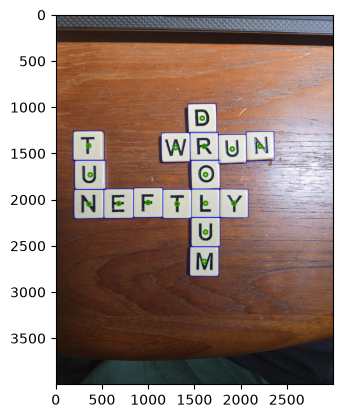

16

In [7]:
drawOn2 = image.copy()

for x1,y1,x2,y2 in boxes:
    xAvg = (x1+x2)//2
    yAvg = (y1+y2)//2
    avgTileLen += x2-x1
    avgTileLen += y2-y1

    cv2.circle(drawOn2, (xAvg,yAvg),20,(50,150,0),20)
    cv2.rectangle(drawOn2, (x1,y1),(x2,y2), (0,0,250),3)

plt.imshow(drawOn2)
plt.show()
len(boxes)

## Crop and export

In [8]:
from cv2.typing import MatLike

def getCropped(image:MatLike, box) -> MatLike:
    x1,y1,x2,y2 = map(int, box)
    croppedImage = image[y1:y2,x1:x2]
    return croppedImage

def exportImage(image:MatLike, fileName, basePath='cnnTraining'):
    fullPath = f'./{basePath}/{fileName}.jpg'
    cv2.imwrite(fullPath,image)

In [9]:
# import os

# batch = 'Batch2'
# imageDir = 'cnnTraining/_Full_Images'
# fullPath = os.path.join(imageDir,batch)
# print(fullPath)
# count = 0

# images = [imageFile for _,_, imageFile in os.walk(fullPath)][0]
# print(images)

# for imageFilePath in images:
#     imageFullPath = os.path.join(fullPath,imageFilePath)
#     image = cv2.imread(imageFullPath)
#     result = myModel.predict(image)
#     boxes = result[0].boxes.xyxy.cpu().numpy()
#     for crop in boxes:
#         croppedImage = getCropped(image,crop)
#         croppedOutPath = os.path.join('cnnTraining',f'{count}.jpg')
#         exportImage(croppedImage,str(count))
#         count+=1


## Determine Letter of Each Box

In [10]:
import torch
import string
from Scananagrams.src.cnn.OCRModel import SingleCharOCR, ImageDataset
from torch.utils.data import DataLoader
from torchvision.transforms import transforms


cv_letters = [ image[y1:y2,x1:x2] for x1,y1,x2,y2 in boxes]
transform = transforms.Compose([
    transforms.Resize((20,20)),
    transforms.ToTensor()
])
dataset = ImageDataset(cv_letters,transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)


model = SingleCharOCR()
model.load_state_dict(torch.load('cnnTraining/weights/firstAttempt.pt', weights_only=True))
model.eval()

outputs = []

with torch.inference_mode():
    for batch in  dataloader:
        outputs.append(model(batch)[0])

outputs = torch.stack(outputs)
outs=torch.argmax(outputs,1)
letters = np.asarray(list(string.ascii_uppercase))
tileLetters = letters[outs]
tileLetters

array(['E', 'R', 'L', 'N', 'H', 'U', 'T', 'C', 'M', 'F', 'D', 'Y', 'U', 'L', 'W', 'C'], dtype='<U1')

## Give each box a letter, create `TileInfo` Objects

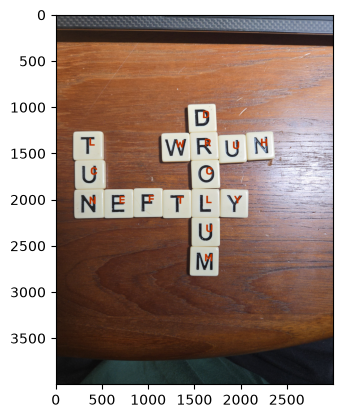

In [11]:
from Scananagrams.src.tiles.TileInfo import TileInfo
from Scananagrams.src.helper import Point

tiles = [TileInfo(id, Point(centerLetter[0][0],centerLetter[0][1]),centerLetter[1]) for id, centerLetter in enumerate(zip(centers,tileLetters))]
drawOnFinal = image.copy()

for tile in tiles:
    # print(tile.letter)
    cv2.putText(drawOnFinal, tile.letter, (tile.center.x,tile.center.y), cv2.FONT_HERSHEY_SIMPLEX, 4.0, (190,50,0),2,bottomLeftOrigin=False)
plt.imshow(drawOnFinal)
plt.show()

## Visualize board with BFS using only letters

### Find All Neighbors

In [12]:
def setAllneighbors(tiles:list[TileInfo], avgTileLen, returnCenterTile = False)-> list[TileInfo] | tuple[list[TileInfo], TileInfo]:
    centers = np.asarray([ [tile.center.x,tile.center.y] for tile in tiles])
    npTiles = np.asarray(tiles)

    neigh = NearestNeighbors(n_neighbors=5, algorithm='ball_tree').fit(centers)
    indices = neigh.kneighbors(centers, return_distance=False)
    nearestNeighbors =  npTiles[indices]

    for neighbors in nearestNeighbors:
        neighbors = findNeighbor(neighbors[0],avgTileLen,neighbors)

    if returnCenterTile:
        #change to median?
        approxCenter = np.average(centers,axis=0)
        centNeigh = neigh.kneighbors([approxCenter], n_neighbors=1, return_distance=False)
        centerTile = tiles[centNeigh[0][0]]
        return tiles, centerTile
    else:
        return tiles

### Find Neighbors

In [13]:
from Scananagrams.src.tiles.TileNeighbors import TileNeighbors

def findNeighbor(tile: TileInfo, avgTileLen: int | float, nearestNeighbors) -> TileNeighbors: 
    moePercent = .3
    neighbors = tile.tileDict
    tileX = tile.center.x
    tileY = tile.center.y

    for adjTile in nearestNeighbors:

        otherX = adjTile.center.x
        otherY = adjTile.center.y

        minX, maxX = helper.addCI(otherX, avgTileLen, moePercent) 
        minY, maxY = helper.addCI(otherY, avgTileLen, moePercent)

        staticXCheck = (minX < tileX < maxX)
        staticYCheck = (minY < tileY <maxY)

        if(neighbors['up'] is None and staticXCheck and (minY + avgTileLen < tileY < maxY+avgTileLen)):
            neighbors['up'] = adjTile
            # adjtile.tileDict['down'] = tile
        
        if( neighbors['down'] is None and staticXCheck and (minY - avgTileLen < tileY < maxY - avgTileLen) ):
            neighbors['down'] = adjTile
            # adjtile.tileDict['up'] = tile

        if(neighbors['left'] is None and staticYCheck and (minX + avgTileLen < tileX < maxX + avgTileLen)):
            neighbors['left'] = adjTile
            # adjtile.tileDict['right'] = tile

        if(neighbors['right'] is None and staticYCheck and (minX - avgTileLen < tileX < maxX - avgTileLen)):
            neighbors['right'] = adjTile
            # adjtile.tileDict['left']=tile

    return neighbors

In [14]:
avgTileLen = helper.findNewAvgTileLen(boxes)

_, cent = setAllneighbors(tiles, avgTileLen,True)
for tile in tiles[0:3]:
    print(tile, tile.tileDict)

Tile: E Position: (681,2042) Neighbors: 'up': None, 'down': None 'left': Tile: N Position: (358,2048), 'right': Tile: F Position: (998,2031)
Tile: R Position: (1605,1423) Neighbors: 'up': Tile: D Position: (1585,1118), 'down': Tile: C Position: (1621,1729) 'left': Tile: W Position: (1298,1437), 'right': Tile: U Position: (1910,1452)
Tile: L Position: (356,1416) Neighbors: 'up': None, 'down': Tile: C Position: (373,1731) 'left': None, 'right': None


In [26]:
minX, minY = centers[np.argmin(centers,axis=0)]
maxX, maxY = centers[np.argmax(centers, axis=0)]
width = round((maxX[0] - minX[0])/avgTileLen)+1
length = round((maxY[1] - minY[1])/avgTileLen)+1

board = np.ndarray((length,width), dtype='<U2')

boardPos = [ Point(-1,-1) for _ in tiles ]

centerX = round( (cent.center.x-minX[0]) /avgTileLen)
centerY = round( (cent.center.y - minY[1]) /avgTileLen)

boardPos[cent.id] = Point(centerX, centerY)

queue:list[TileInfo] = []
traversed = [False] * len(tiles)

queue.append(cent)
traversed[cent.id] = True

while queue:
    cur = queue.pop(0)
    curPos = boardPos[cur.id]
    curAdj = cur.tileDict

    for x in curAdj.neighbors.keys():
        adj = curAdj[x]
        if(adj is not None and traversed[adj.id]==False ):
            adjId = adj.id
            queue.append(adj)
            traversed[adjId] = True

            match x:
                case 'up':
                    boardPos[adjId] = Point(curPos.x, curPos.y-1)
                case 'down':
                    boardPos[adjId] = Point(curPos.x, curPos.y+1)
                case 'left':
                    boardPos[adjId] = Point(curPos.x-1,curPos.y)
                case 'right': 
                    boardPos[adjId] = Point(curPos.x+1,curPos.y)

board[:,:] = " "
for id, pos in enumerate(boardPos):
    board[pos.y,pos.x]= tiles[id].letter

board
            

            




array([[' ', ' ', ' ', ' ', 'D', ' ', ' '],
       ['L', ' ', ' ', 'W', 'R', 'U', 'H'],
       ['C', ' ', ' ', ' ', 'C', ' ', ' '],
       ['N', 'E', 'F', 'T', 'L', 'Y', ' '],
       [' ', ' ', ' ', ' ', 'U', ' ', ' '],
       [' ', ' ', ' ', ' ', 'M', ' ', ' ']], dtype='<U2')

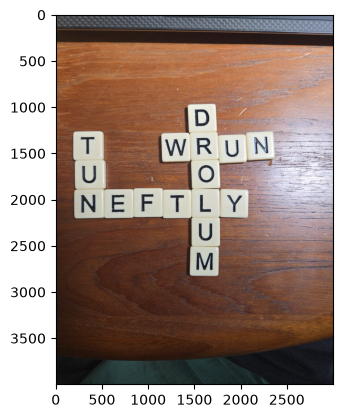

[[' ' ' ' ' ' ' ' 'D' ' ' ' ']
 ['L' ' ' ' ' 'W' 'R' 'U' 'H']
 ['C' ' ' ' ' ' ' 'C' ' ' ' ']
 ['N' 'E' 'F' 'T' 'L' 'Y' ' ']
 [' ' ' ' ' ' ' ' 'U' ' ' ' ']
 [' ' ' ' ' ' ' ' 'M' ' ' ' ']]


In [27]:
plt.imshow(image)
plt.show()
print(board)

## Letters --> Words

## Visualize board using words and intersect indices

## Neighbors 1